In [6]:
# Импорт библиотек
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка файла
uploaded = files.upload()

# Читаем CSV
df = pd.read_csv('gold_futures_timeseries.csv')

print("✅ Датасет успешно загружен!")

Saving gold_futures_timeseries.csv to gold_futures_timeseries (1).csv
✅ Датасет успешно загружен!


In [7]:
# 1. Первые и последние строки
print("=== ПЕРВЫЕ 5 СТРОК ===")
display(df.head())
print("\n=== ПОСЛЕДНИЕ 5 СТРОК ===")
display(df.tail())

# Размер датасета
print(f"\nРазмер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов")

# Типы данных
print("\nТипы данных:")
print(df.dtypes)

# Пропущенные значения
print("\nПропущенные значения:")
print(df.isnull().sum())
print(f"Всего пропусков: {df.isnull().sum().sum()}")

=== ПЕРВЫЕ 5 СТРОК ===


,date,open,high,low,close,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
0,2021-07-15,1828.4,1833.0,1823.4,1831.6,99,1807.8143,1821.0300,1794.8378,1.0204,0.3921,0.9204,77.0256,-5.6307,-12.2447,1825.2034,1753.8266
1,2021-07-16,1814.5,1831.4,1814.5,1830.1,78,1812.3000,1818.4067,1796.4367,-0.0819,0.3943,0.9129,76.7894,-3.1756,-10.4309,1829.3189,1751.5410
2,2021-07-19,1808.7,1813.4,1803.3,1803.3,33,1813.2000,1816.2067,1797.4333,-1.4644,0.7616,0.8746,59.6577,-3.3538,-9.0154,1830.4561,1753.1639
3,2021-07-20,1810.9,1824.0,1810.9,1812.9,128,1814.5286,1813.6200,1798.4033,0.5324,0.7754,0.8516,63.9382,-2.6894,-7.7502,1832.1624,1755.8675
4,2021-07-21,1802.9,1807.0,1800.0,1807.0,135,1815.1571,1810.6367,1799.4156,-0.3254,0.7897,0.8479,69.1730,-2.6088,-6.7220,1833.4198,1756.9701



=== ПОСЛЕДНИЕ 5 СТРОК ===


,date,open,high,low,close,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
1164,2026-03-03,5107.3999,5303.7998,5023.0000,5298.7002,1776,5207.7572,5039.9634,4501.2556,-0.8959,1.2815,3.1961,65.9973,123.1731,109.8991,5367.0596,4719.8305
1165,2026-03-04,5120.2002,5180.2002,5117.2002,5130.7002,679,5209.2430,5055.5800,4512.6000,-3.1706,1.8713,3.2630,53.9492,112.2639,110.3720,5342.3531,4789.6069
1166,2026-03-05,5065.2998,5169.5000,5054.7002,5169.5000,1701,5210.7716,5065.7800,4524.7234,0.7562,1.8716,3.1782,55.1888,105.5326,109.4042,5349.7938,4806.7863
1167,2026-03-06,5146.1001,5146.1001,5076.1001,5121.0000,1701,5204.3430,5076.7500,4535.8734,-0.9382,1.9065,3.1697,58.4643,95.1872,106.5608,5353.9903,4813.8198
1168,2026-03-09,5114.6001,5210.3999,5021.2002,5186.7002,135914,5205.7001,5084.6534,4548.3923,1.2830,1.9781,3.1246,58.4099,91.2381,103.4962,5331.9807,4878.2994



Размер датасета: 1169 строк и 17 столбцов

Типы данных:
date              object
open             float64
high             float64
low              float64
close            float64
volume             int64
ma_7             float64
ma_30            float64
ma_90            float64
daily_return     float64
volatility_7     float64
volatility_30    float64
rsi              float64
macd             float64
macd_signal      float64
bb_upper         float64
bb_lower         float64
dtype: object

Пропущенные значения:
date             0
open             0
high             0
low              0
close            0
volume           0
ma_7             0
ma_30            0
ma_90            0
daily_return     0
volatility_7     0
volatility_30    0
rsi              0
macd             0
macd_signal      0
bb_upper         0
bb_lower         0
dtype: int64
Всего пропусков: 0


In [8]:
# Если пропусков нет — добавляем искусственно
if df.isnull().sum().sum() == 0:
    print("Пропусков нет. Добавляем искусственные пропуски ...")
    np.random.seed(42)
    cols_to_miss = ['open', 'high', 'low', 'close', 'volume', 'ma_7', 'rsi', 'macd']
    mask = np.random.rand(len(df)) < 0.05  # 5% строк

    for col in cols_to_miss:
        df.loc[mask, col] = np.nan

    print(f"Добавлено пропусков: {df.isnull().sum().sum()}")

# Обработка пропусков
print("\nОбработка пропусков...")

df = df.ffill()


print("Пропуски после обработки:")
print(df.isnull().sum())

# Дубликаты
duplicates = df.duplicated().sum()
print(f"\nДубликатов: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Дубликаты удалены")

# Приведение типов
df['date'] = pd.to_datetime(df['date'])
print("\nТипы данных после приведения:")
print(df.dtypes)

Пропусков нет. Добавляем искусственные пропуски ...
Добавлено пропусков: 504

Обработка пропусков...
Пропуски после обработки:
date             0
open             0
high             0
low              0
close            0
volume           0
ma_7             0
ma_30            0
ma_90            0
daily_return     0
volatility_7     0
volatility_30    0
rsi              0
macd             0
macd_signal      0
bb_upper         0
bb_lower         0
dtype: int64

Дубликатов: 0

Типы данных после приведения:
date             datetime64[ns]
open                    float64
high                    float64
low                     float64
close                   float64
volume                  float64
ma_7                    float64
ma_30                   float64
ma_90                   float64
daily_return            float64
volatility_7            float64
volatility_30           float64
rsi                     float64
macd                    float64
macd_signal             float64
bb_upper   

In [9]:
# Основные статистики
print("=== Основные статистические показатели ===")
display(df.describe().round(2))

# Группировка по годам (пример полезной группировки)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("\nСредняя цена закрытия по годам:")
yearly = df.groupby('year')['close'].agg(['mean', 'min', 'max', 'std']).round(2)
display(yearly)

# Топ-5 самых высоких цен закрытия
print("\nТоп-5 самых высоких цен закрытия:")
display(df.nlargest(5, 'close')[['date', 'close', 'high', 'low', 'volume']])

# Топ-5 самых высоких объёмов торгов
print("\nТоп-5 самых высоких объёмов торгов:")
display(df.nlargest(5, 'volume')[['date', 'close', 'volume']])

# Баланс классов — в этом датасете нет категориальной целевой переменной
# (это временной ряд), поэтому просто отмечаем:
print("\nБаланс классов: датасет содержит только числовые признаки (регрессия/временной ряд).")

=== Основные статистические показатели ===


,date,open,high,low,close,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
count,1169,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00,1169.00
mean,2023-11-09 13:39:09.700598784,2431.52,2444.88,2416.83,2430.18,4442.01,2421.95,2389.80,2317.64,0.10,0.96,1.00,55.51,18.95,18.61,2495.06,2312.01
min,2021-07-15 00:00:00,1623.30,1623.30,1615.10,1620.40,0.00,1643.50,1658.10,1705.04,-10.58,0.14,0.42,9.72,-36.07,-32.21,1682.42,1575.38
25%,2022-09-12 00:00:00,1834.80,1842.00,1824.90,1835.30,94.00,1833.56,1833.34,1817.36,-0.43,0.64,0.78,43.36,-3.91,-3.70,1884.31,1778.86
50%,2023-11-08 00:00:00,2002.60,2014.50,1994.70,2004.10,302.00,2007.77,1992.94,1956.39,0.09,0.84,0.91,54.79,10.60,10.31,2049.71,1943.75
75%,2025-01-08 00:00:00,2738.30,2742.90,2728.60,2736.10,885.00,2727.51,2684.47,2639.61,0.66,1.11,1.06,67.64,30.72,30.54,2805.81,2592.86
max,2026-03-09 00:00:00,5318.40,5586.20,5301.60,5415.70,209783.00,5210.77,5084.65,4548.39,5.36,5.73,3.26,96.70,251.42,187.92,5429.95,4878.30
std,NaN,838.85,849.22,827.74,838.67,22313.38,827.29,783.40,687.93,1.11,0.56,0.42,17.20,35.02,33.24,868.88,738.95



Средняя цена закрытия по годам:


,mean,min,max,std
year,,,,
2021,1791.27,1725.5,1864.5,28.78
2022,1799.34,1620.4,2053.6,93.62
2023,1943.02,1808.1,2081.6,60.63
2024,2389.05,1990.3,2787.4,224.17
2025,3440.60,2633.0,4512.0,481.69
2026,4916.93,4350.6,5415.7,290.20



Топ-5 самых высоких цен закрытия:


,date,close,high,low,volume
1142,2026-01-29,5415.7002,5586.2002,5097.5000,23709.0
1143,2026-01-30,5376.3999,5440.5000,4700.0000,8374.0
1163,2026-03-02,5346.6001,5405.0000,5266.2998,72.0
1141,2026-01-28,5301.6001,5301.6001,5301.6001,112054.0
1164,2026-03-03,5298.7002,5303.7998,5023.0000,1776.0



Топ-5 самых высоких объёмов торгов:


,date,close,volume
9,2021-07-28,1799.5,209783.0
10,2021-07-29,1799.5,209783.0
678,2024-03-26,2182.7,202373.0
136,2022-01-27,1793.3,196036.0
511,2023-07-27,1945.4,194253.0



Баланс классов: датасет содержит только числовые признаки (регрессия/временной ряд).


In [10]:
print("=== ВЫВОД О НАБОРЕ ДАННЫХ ===")
print("""
Ключевые наблюдения:
• Самые важные столбцы:
  - date (индекс времени)
  - close (целевая переменная для прогнозирования)
  - open, high, low, volume (базовые биржевые данные)
  - ma_7, ma_30, ma_90, rsi, macd, bb_upper, bb_lower (технические индикаторы — очень полезны)

• Закономерности без ML:
  - Цена золота имеет долгосрочный восходящий тренд (с 2021 по 2026 выросла более чем в 2 раза)
  - Сильная волатильность в 2025–2026 годах (видно по росту volatility_30 и резким скачкам close)
  - Объёмы торгов резко растут в моменты сильных движений цены


Датасет чистый, готов к моделям прогнозирования (LSTM, Prophet, ARIMA и т.д.).
""")

=== ВЫВОД О НАБОРЕ ДАННЫХ ===

Ключевые наблюдения:
• Самые важные столбцы:
  - date (индекс времени)
  - close (целевая переменная для прогнозирования)
  - open, high, low, volume (базовые биржевые данные)
  - ma_7, ma_30, ma_90, rsi, macd, bb_upper, bb_lower (технические индикаторы — очень полезны)

• Закономерности без ML:
  - Цена золота имеет долгосрочный восходящий тренд (с 2021 по 2026 выросла более чем в 2 раза)
  - Сильная волатильность в 2025–2026 годах (видно по росту volatility_30 и резким скачкам close)
  - Объёмы торгов резко растут в моменты сильных движений цены


Датасет чистый, готов к моделям прогнозирования (LSTM, Prophet, ARIMA и т.д.).



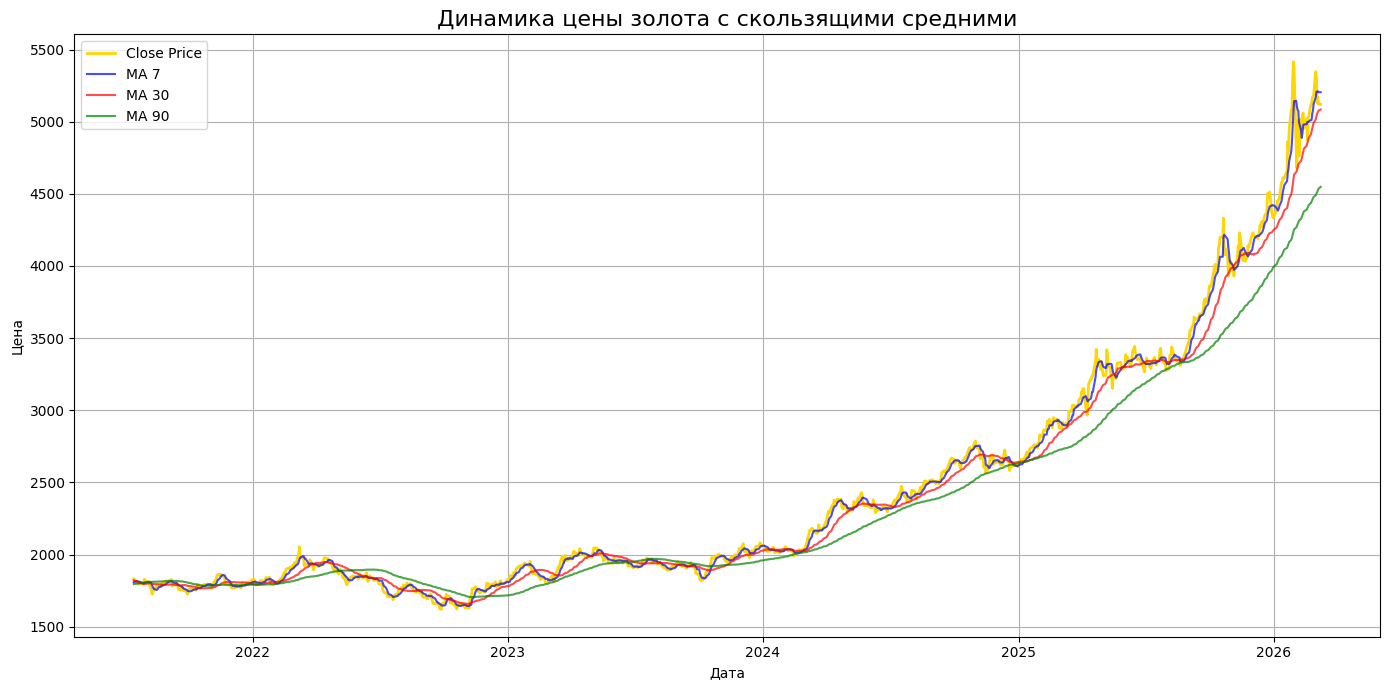

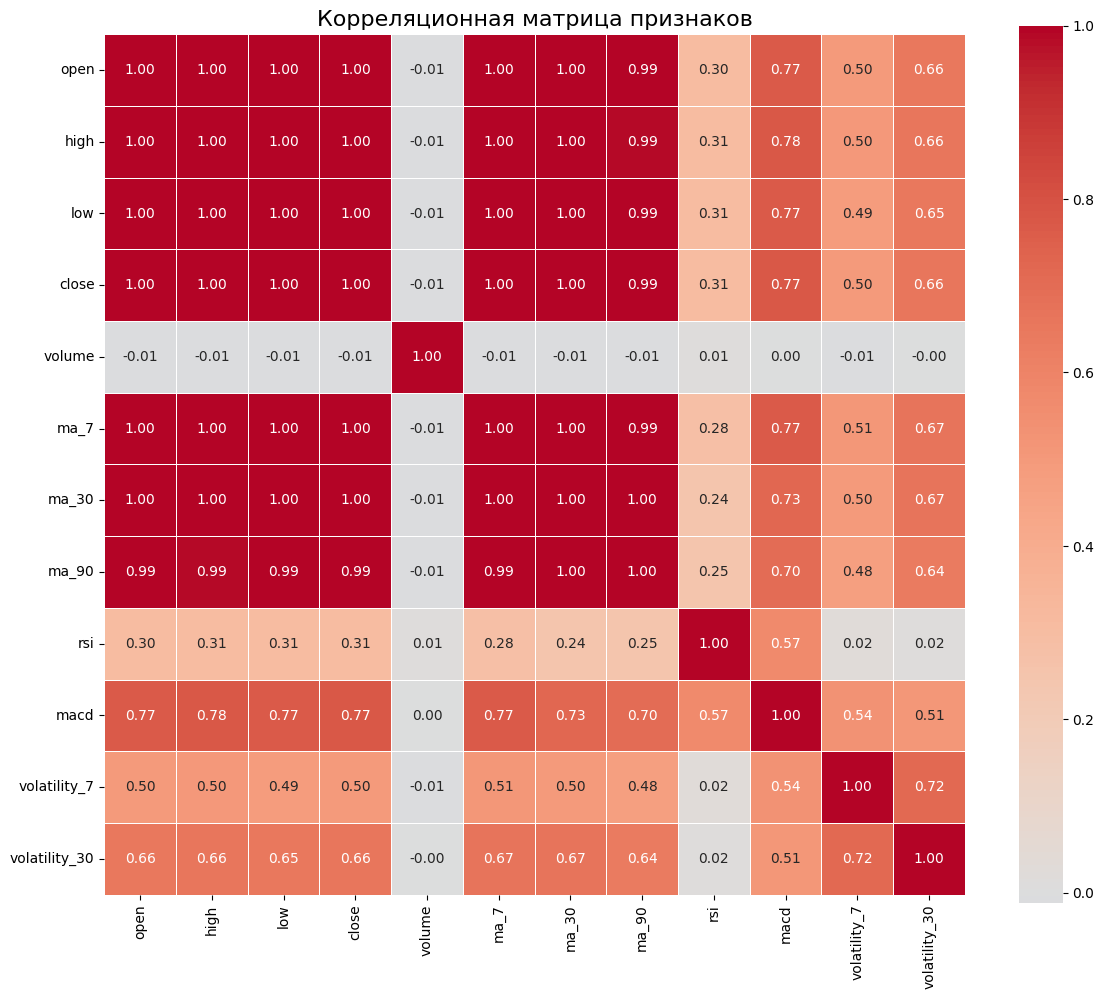

In [15]:
# ==================== График 1: Цена + Скользящие средние ====================
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['close'], label='Close Price', color='gold', linewidth=2)
plt.plot(df['date'], df['ma_7'], label='MA 7', color='blue', alpha=0.7)
plt.plot(df['date'], df['ma_30'], label='MA 30', color='red', alpha=0.7)
plt.plot(df['date'], df['ma_90'], label='MA 90', color='green', alpha=0.7)

plt.title('Динамика цены золота с скользящими средними', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==================== График 2: Корреляционная матрица ====================
plt.figure(figsize=(12, 10))
numeric_cols = ['open', 'high', 'low', 'close', 'volume',
                'ma_7', 'ma_30', 'ma_90', 'rsi', 'macd',
                'volatility_7', 'volatility_30']

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков', fontsize=16)
plt.tight_layout()
plt.show()
